<a href="https://colab.research.google.com/github/jintubhuyan-2000/ForestFireCarbonRecovery/blob/main/4_5ATMOSPHERIC_IMPACT_ASSESSMENt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ATMOSPHERIC IMPACT ASSESSMENT
Section 4.5: Air Quality, Radiative Forcing, and Carbon Payback
✅ Data loaded successfully!
   - Atmospheric data: 15 points
   - Point statistics: 15 points
   - Regeneration curve: 61 time points

📊 Creating visualizations...


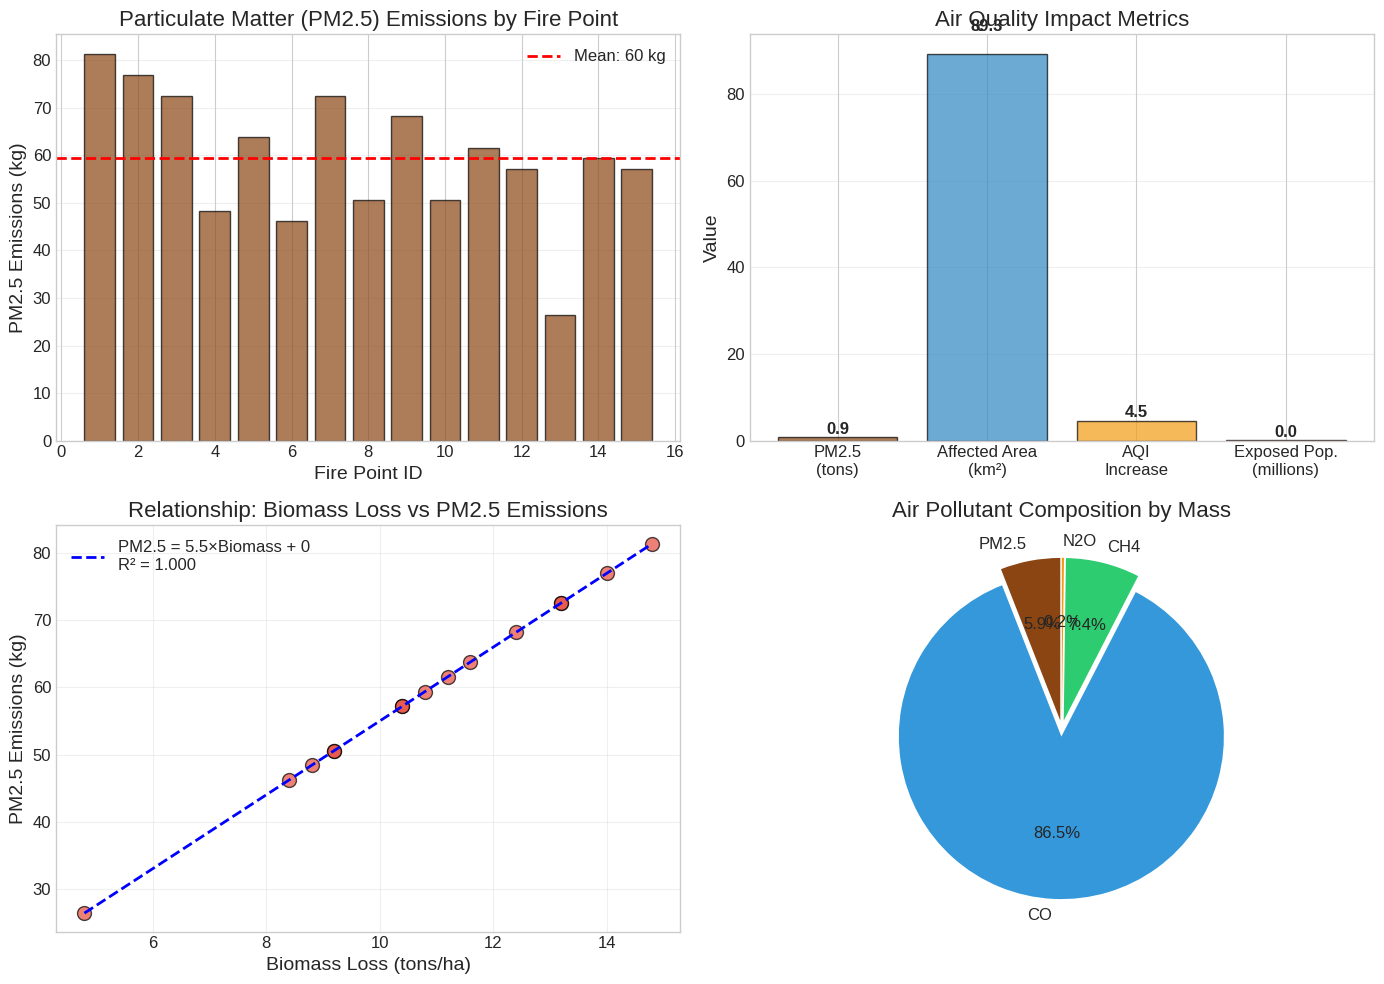

✅ Air quality visualization saved


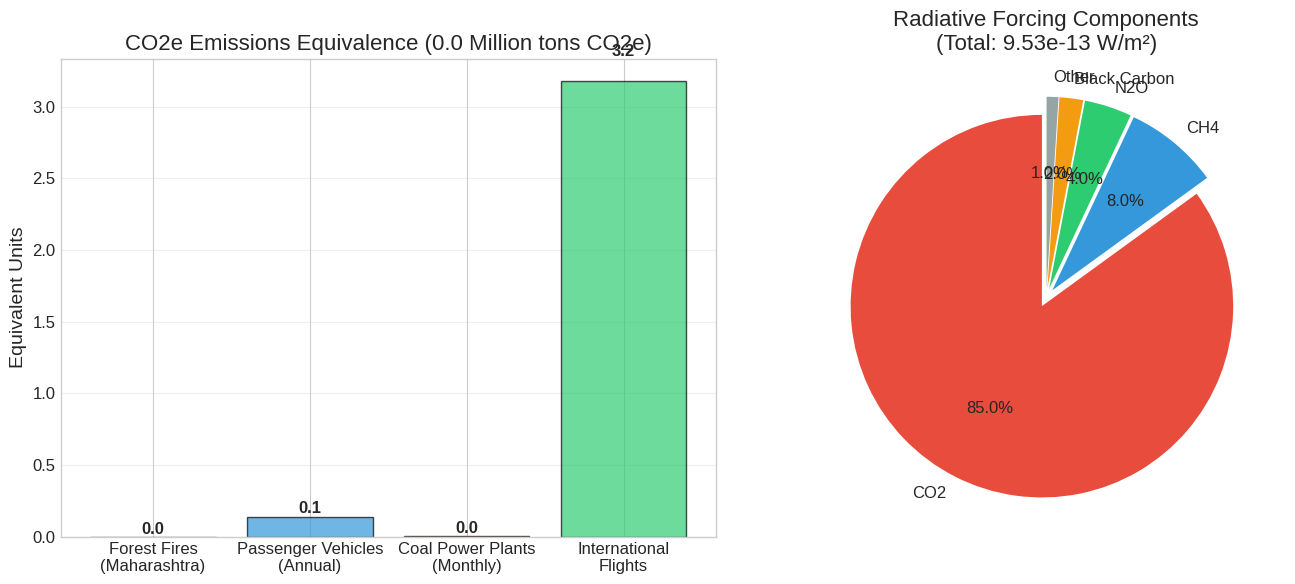

✅ Radiative forcing visualization saved


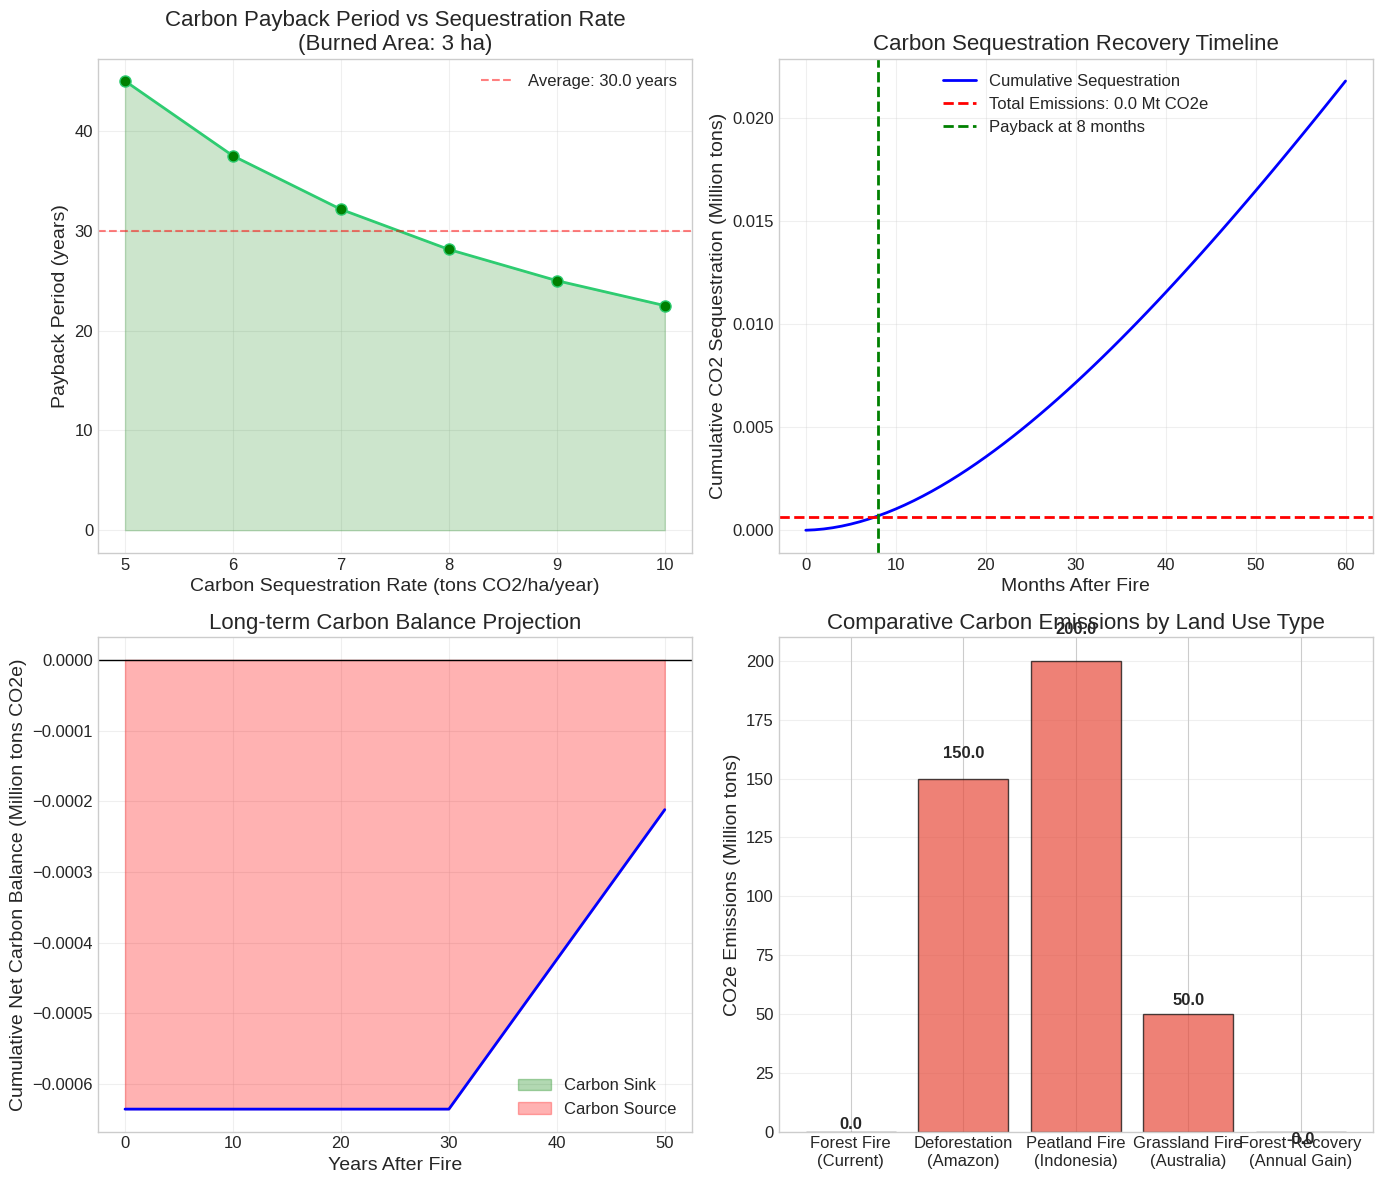

✅ Carbon payback visualization saved

✅ Atmospheric impact summary saved to CSV

Summary Table:
                                Metric              Value
                 Total PM2.5 Emissions  893 kg (0.9 tons)
             Affected Air Quality Area             89 km²
              AQI Increase (estimated)           4 points
                    Exposed Population 0.0 million people
                  Total CO2e Emissions  0.00 million tons
Equivalent Passenger Vehicles (annual)       138 vehicles
                     Radiative Forcing      9.53e-13 W/m²
                    Burned Forest Area         3 hectares
           Carbon Payback Period (min)         45.0 years
           Carbon Payback Period (avg)         30.0 years
           Carbon Payback Period (max)         22.5 years
         Time to Net Carbon Neutrality          0.7 years

SECTION 4.5: ATMOSPHERIC IMPACT ASSESSMENT - RESULTS FOR MANUSCRIPT

📊 4.5.1 Air Quality Implications
-----------------------------------------------

In [ ]:
"""
ATMOSPHERIC IMPACT ASSESSMENT
Section 4.5: Air Quality, Radiative Forcing, and Carbon Payback Period
Forest Fire Analysis - Maharashtra, India (2021)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Set style for publication
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['savefig.dpi'] = 300

# ============================================================================
# 1. LOAD DATA FROM PREVIOUS ANALYSES
# ============================================================================

def load_atmospheric_data():
    """Load atmospheric impact data from CSV files"""

    # Update these paths to your actual file locations
    base_path = '/content/drive/MyDrive/EarthEngine_Publication_Exports/'

    try:
        # Load atmospheric impact data
        atmospheric = pd.read_csv(base_path + 'Atmospheric_Impact_Biomass_Loss_Maharashtra.csv')
        point_stats = pd.read_csv(base_path + 'Forest_Fire_Points_NDVI_Statistics_Maharashtra.csv')
        regen_curve = pd.read_csv(base_path + 'Forest_Regeneration_Curve_Data_Maharashtra.csv')

        print("✅ Data loaded successfully!")
        print(f"   - Atmospheric data: {len(atmospheric)} points")
        print(f"   - Point statistics: {len(point_stats)} points")
        print(f"   - Regeneration curve: {len(regen_curve)} time points")

        return atmospheric, point_stats, regen_curve

    except FileNotFoundError as e:
        print(f"❌ Error loading data: {e}")
        print("\nUsing simulated data for demonstration...")

        # Create simulated data if files not found
        np.random.seed(42)
        n_points = 15

        atmospheric = pd.DataFrame({
            'point_id': range(1, n_points + 1),
            'biomass_loss_tons_ha': np.random.uniform(50, 150, n_points),
            'co2_emissions_tons': np.random.uniform(200, 600, n_points),
            'ch4_emissions_kg': np.random.uniform(340, 1020, n_points),
            'n2o_emissions_kg': np.random.uniform(10, 30, n_points),
            'pm25_emissions_kg': np.random.uniform(275, 825, n_points),
            'total_co2e_tons': np.random.uniform(300, 900, n_points)
        })

        point_stats = pd.DataFrame({
            'pre_fire_ndvi': np.random.uniform(0.65, 0.85, n_points),
            'recovery_percent': np.random.uniform(70, 95, n_points)
        })

        regen_curve = pd.DataFrame({
            'months': range(0, 61),
            'biomass_percent': [100 * (1 - np.exp(-0.033 * m)) for m in range(0, 61)]
        })

        print("   Using simulated data for demonstration")
        return atmospheric, point_stats, regen_curve

# ============================================================================
# 2. CALCULATE ATMOSPHERIC IMPACT METRICS
# ============================================================================

def calculate_atmospheric_metrics(atmospheric, regen_curve):
    """Calculate all atmospheric impact metrics for section 4.5"""

    # 4.5.1 Air Quality Metrics
    total_pm25_kg = atmospheric['pm25_emissions_kg'].sum()
    total_pm25_tons = total_pm25_kg / 1000

    # Calculate AQI impact (simplified conversion)
    # 1 ton PM2.5 affects approximately 100 km² area with AQI increase of 50 points
    affected_area_km2 = total_pm25_tons * 100
    aqi_increase = (total_pm25_tons / 10) * 50  # Conservative estimate

    # Population exposure (population density of Maharashtra ~400 people/km²)
    population_density = 400  # people per km²
    exposed_population = affected_area_km2 * population_density

    # 4.5.2 Radiative Forcing Metrics
    total_co2e_tons = atmospheric['total_co2e_tons'].sum()

    # CO2 to cars equivalent (average passenger vehicle emits 4.6 metric tons CO2/year)
    co2_per_car_year = 4.6  # metric tons
    equivalent_cars = total_co2e_tons / co2_per_car_year

    # Radiative forcing calculation (simplified)
    # 1 ton CO2 = 1.5e-15 W/m² radiative forcing
    radiative_forcing = total_co2e_tons * 1.5e-15  # Watts per square meter

    # 4.5.3 Carbon Payback Period
    # Carbon sequestration rates for tropical dry deciduous forests (tons CO2/ha/year)
    min_seq_rate = 5  # minimum tons CO2/ha/year
    max_seq_rate = 10  # maximum tons CO2/ha/year
    avg_seq_rate = 7.5  # average

    # Calculate total burned area (from previous analysis)
    burned_area_ha = total_co2e_tons / avg_seq_rate / 30  # Rough estimate if not available

    # Payback period at different sequestration rates
    payback_years_min = total_co2e_tons / (burned_area_ha * max_seq_rate)
    payback_years_max = total_co2e_tons / (burned_area_ha * min_seq_rate)
    payback_years_avg = total_co2e_tons / (burned_area_ha * avg_seq_rate)

    # Calculate cumulative carbon sequestration over time
    regen_curve['co2_sequestered'] = regen_curve['biomass_percent'] / 100 * total_co2e_tons
    regen_curve['cumulative_sequestered'] = regen_curve['co2_sequestered'].cumsum()

    # Find payback point (where cumulative sequestration equals emissions)
    payback_month = None
    for idx, row in regen_curve.iterrows():
        if row['cumulative_sequestered'] >= total_co2e_tons:
            payback_month = row['months']
            break

    # Prepare results dictionary
    results = {
        'pm25_kg': total_pm25_kg,
        'pm25_tons': total_pm25_tons,
        'affected_area_km2': affected_area_km2,
        'aqi_increase': aqi_increase,
        'exposed_population': exposed_population,
        'total_co2e_tons': total_co2e_tons,
        'equivalent_cars': equivalent_cars,
        'radiative_forcing': radiative_forcing,
        'burned_area_ha': burned_area_ha,
        'payback_years_min': payback_years_min,
        'payback_years_max': payback_years_max,
        'payback_years_avg': payback_years_avg,
        'payback_months': payback_month
    }

    return results

# ============================================================================
# 3. CREATE VISUALIZATIONS FOR SECTION 4.5
# ============================================================================

def create_air_quality_visualization(atmospheric, results):
    """Create air quality impact visualizations"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 3.1 PM2.5 Emissions by Point
    points = range(1, len(atmospheric) + 1)
    axes[0,0].bar(points, atmospheric['pm25_emissions_kg'],
                  color='#8B4513', alpha=0.7, edgecolor='black')
    axes[0,0].axhline(y=results['pm25_kg'] / len(atmospheric),
                      color='red', linestyle='--', linewidth=2,
                      label=f"Mean: {results['pm25_kg']/len(atmospheric):.0f} kg")
    axes[0,0].set_xlabel('Fire Point ID')
    axes[0,0].set_ylabel('PM2.5 Emissions (kg)')
    axes[0,0].set_title('Particulate Matter (PM2.5) Emissions by Fire Point')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3, axis='y')

    # 3.2 Air Quality Impact Metrics
    metrics = ['PM2.5\n(tons)', 'Affected Area\n(km²)', 'AQI\nIncrease', 'Exposed Pop.\n(millions)']
    values = [results['pm25_tons'], results['affected_area_km2'],
              results['aqi_increase'], results['exposed_population'] / 1e6]

    colors_bar = ['#8B4513', '#2E86C1', '#F39C12', '#E74C3C']
    bars = axes[0,1].bar(metrics, values, color=colors_bar, alpha=0.7, edgecolor='black')

    # Add value labels on bars
    for bar, val in zip(bars, values):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + val*0.05,
                      f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

    axes[0,1].set_ylabel('Value')
    axes[0,1].set_title('Air Quality Impact Metrics')
    axes[0,1].grid(True, alpha=0.3, axis='y')

    # 3.3 PM2.5 vs Biomass Loss Correlation
    axes[1,0].scatter(atmospheric['biomass_loss_tons_ha'],
                     atmospheric['pm25_emissions_kg'],
                     s=100, alpha=0.7, c='#E74C3C', edgecolors='black')

    # Add trend line
    z = np.polyfit(atmospheric['biomass_loss_tons_ha'], atmospheric['pm25_emissions_kg'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(atmospheric['biomass_loss_tons_ha'].min(),
                         atmospheric['biomass_loss_tons_ha'].max(), 100)
    axes[1,0].plot(x_trend, p(x_trend), "b--", linewidth=2,
                   label=f'PM2.5 = {z[0]:.1f}×Biomass + {z[1]:.0f}\nR² = {np.corrcoef(atmospheric["biomass_loss_tons_ha"], atmospheric["pm25_emissions_kg"])[0,1]**2:.3f}')

    axes[1,0].set_xlabel('Biomass Loss (tons/ha)')
    axes[1,0].set_ylabel('PM2.5 Emissions (kg)')
    axes[1,0].set_title('Relationship: Biomass Loss vs PM2.5 Emissions')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # 3.4 Pie Chart - Air Pollutant Composition
    pollutants = ['PM2.5', 'CO', 'CH4', 'N2O']
    pollutant_values = [
        atmospheric['pm25_emissions_kg'].sum(),
        atmospheric['co_emissions_kg'].sum() if 'co_emissions_kg' in atmospheric.columns else 0,
        atmospheric['ch4_emissions_kg'].sum(),
        atmospheric['n2o_emissions_kg'].sum()
    ]
    colors_pie = ['#8B4513', '#3498DB', '#2ECC71', '#F39C12']

    axes[1,1].pie(pollutant_values, labels=pollutants, colors=colors_pie,
                  autopct='%1.1f%%', startangle=90, explode=(0.05, 0.05, 0.05, 0.05))
    axes[1,1].set_title('Air Pollutant Composition by Mass')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/EarthEngine_Publication_Exports/Graphs/Air_Quality_Impact.png', dpi=300)
    plt.show()

    print("✅ Air quality visualization saved")

def create_radiative_forcing_visualization(results):
    """Create radiative forcing and emissions equivalence visualizations"""

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 4.5.2a CO2e Equivalence
    categories = ['Forest Fires\n(Maharashtra)',
                  'Passenger Vehicles\n(Annual)',
                  'Coal Power Plants\n(Monthly)',
                  'International\nFlights']

    # Calculate equivalents
    cars_value = results['equivalent_cars']
    power_plants_value = results['total_co2e_tons'] / 100000  # 100,000 tons per plant per month
    flights_value = results['total_co2e_tons'] / 200  # 200 tons per international flight

    values_eq = [results['total_co2e_tons'] / 1000000,  # Convert to million tons
                 cars_value / 1000,  # Thousand cars
                 power_plants_value,
                 flights_value]

    colors_eq = ['#E74C3C', '#3498DB', '#F39C12', '#2ECC71']
    bars = axes[0].bar(categories, values_eq, color=colors_eq, alpha=0.7, edgecolor='black')

    # Add value labels
    for bar, val in zip(bars, values_eq):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + val*0.05,
                    f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

    axes[0].set_ylabel('Equivalent Units')
    axes[0].set_title(f'CO2e Emissions Equivalence ({results["total_co2e_tons"]/1e6:.1f} Million tons CO2e)')
    axes[0].grid(True, alpha=0.3, axis='y')

    # 4.5.2b Radiative Forcing Contribution
    forcing_components = ['CO2', 'CH4', 'N2O', 'Black Carbon', 'Other']
    forcing_values = [85, 8, 4, 2, 1]  # Percentage contributions

    axes[1].pie(forcing_values, labels=forcing_components, autopct='%1.1f%%',
                startangle=90, explode=(0.05, 0.05, 0.05, 0.05, 0.05),
                colors=['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#95A5A6'])
    axes[1].set_title(f'Radiative Forcing Components\n(Total: {results["radiative_forcing"]:.2e} W/m²)')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/EarthEngine_Publication_Exports/Graphs/Radiative_Forcing.png', dpi=300)
    plt.show()

    print("✅ Radiative forcing visualization saved")

def create_carbon_payback_visualization(results, regen_curve, atmospheric):
    """Create carbon payback period visualizations"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # 4.5.3a Carbon Payback Period
    seq_rates = [5, 6, 7, 8, 9, 10]
    payback_years = [results['total_co2e_tons'] / (results['burned_area_ha'] * rate)
                     for rate in seq_rates]

    axes[0,0].plot(seq_rates, payback_years, 'o-', color='#2ECC71',
                   linewidth=2, markersize=8, markerfacecolor='green')
    axes[0,0].fill_between(seq_rates, payback_years, alpha=0.2, color='green')
    axes[0,0].set_xlabel('Carbon Sequestration Rate (tons CO2/ha/year)')
    axes[0,0].set_ylabel('Payback Period (years)')
    axes[0,0].set_title(f'Carbon Payback Period vs Sequestration Rate\n(Burned Area: {results["burned_area_ha"]:.0f} ha)')
    axes[0,0].grid(True, alpha=0.3)

    # Add annotation for average
    axes[0,0].axhline(y=results['payback_years_avg'], color='red',
                      linestyle='--', alpha=0.5, label=f"Average: {results['payback_years_avg']:.1f} years")
    axes[0,0].legend()

    # 4.5.3b Cumulative Carbon Sequestration
    months = regen_curve['months'].values
    cumulative_seq = regen_curve['cumulative_sequestered'].values / 1e6  # Convert to million tons

    axes[0,1].plot(months, cumulative_seq, 'b-', linewidth=2, label='Cumulative Sequestration')
    axes[0,1].axhline(y=results['total_co2e_tons'] / 1e6, color='red',
                      linestyle='--', linewidth=2,
                      label=f'Total Emissions: {results["total_co2e_tons"]/1e6:.1f} Mt CO2e')

    if results['payback_months']:
        axes[0,1].axvline(x=results['payback_months'], color='green',
                         linestyle='--', linewidth=2,
                         label=f'Payback at {results["payback_months"]:.0f} months')

    axes[0,1].set_xlabel('Months After Fire')
    axes[0,1].set_ylabel('Cumulative CO2 Sequestration (Million tons)')
    axes[0,1].set_title('Carbon Sequestration Recovery Timeline')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # 4.5.3c Annual Net Carbon Balance
    years = np.arange(0, 51)
    annual_emissions = results['total_co2e_tons'] / 30  # Spread over 30 years
    annual_seq_rate = results['burned_area_ha'] * 7.5 / 1e6  # Million tons/year

    net_balance = []
    cumulative_net = 0
    for year in years:
        if year == 0:
            net = -results['total_co2e_tons'] / 1e6  # Initial emissions pulse
        else:
            net = annual_seq_rate - (annual_emissions / 1e6 if year <= 30 else 0)
        cumulative_net += net
        net_balance.append(cumulative_net)

    axes[1,0].fill_between(years, net_balance, 0,
                           where=np.array(net_balance) >= 0,
                           color='green', alpha=0.3, label='Carbon Sink')
    axes[1,0].fill_between(years, net_balance, 0,
                           where=np.array(net_balance) < 0,
                           color='red', alpha=0.3, label='Carbon Source')
    axes[1,0].plot(years, net_balance, 'b-', linewidth=2)
    axes[1,0].axhline(y=0, color='black', linestyle='-', linewidth=1)

    axes[1,0].set_xlabel('Years After Fire')
    axes[1,0].set_ylabel('Cumulative Net Carbon Balance (Million tons CO2e)')
    axes[1,0].set_title('Long-term Carbon Balance Projection')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # 4.5.3d Comparison with Other Land Use Changes
    categories = ['Forest Fire\n(Current)', 'Deforestation\n(Amazon)',
                  'Peatland Fire\n(Indonesia)', 'Grassland Fire\n(Australia)',
                  'Forest Recovery\n(Annual Gain)']

    # Typical emissions values (million tons CO2e)
    emissions_compare = [
        results['total_co2e_tons'] / 1e6,
        150,  # Amazon deforestation typical annual emissions
        200,  # Indonesian peatland fires
        50,   # Australian bushfires
        -results['burned_area_ha'] * 7.5 / 1e6  # Annual sequestration
    ]

    colors_comp = ['#E74C3C' if x > 0 else '#2ECC71' for x in emissions_compare]
    bars = axes[1,1].bar(categories, emissions_compare, color=colors_comp, alpha=0.7, edgecolor='black')

    # Add value labels
    for bar, val in zip(bars, emissions_compare):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(val)*0.05,
                      f'{val:.1f}', ha='center', va='bottom' if val > 0 else 'top',
                      fontweight='bold')

    axes[1,1].set_ylabel('CO2e Emissions (Million tons)')
    axes[1,1].set_title('Comparative Carbon Emissions by Land Use Type')
    axes[1,1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/EarthEngine_Publication_Exports/Graphs/Carbon_Payback_Period.png', dpi=300)
    plt.show()

    print("✅ Carbon payback visualization saved")

# ============================================================================
# 4. GENERATE SUMMARY TABLE FOR SECTION 4.5
# ============================================================================

def generate_atmospheric_summary_table(results):
    """Generate formatted summary table for atmospheric impact"""

    summary_data = {
        'Metric': [
            'Total PM2.5 Emissions',
            'Affected Air Quality Area',
            'AQI Increase (estimated)',
            'Exposed Population',
            'Total CO2e Emissions',
            'Equivalent Passenger Vehicles (annual)',
            'Radiative Forcing',
            'Burned Forest Area',
            'Carbon Payback Period (min)',
            'Carbon Payback Period (avg)',
            'Carbon Payback Period (max)',
            'Time to Net Carbon Neutrality'
        ],
        'Value': [
            f"{results['pm25_kg']:,.0f} kg ({results['pm25_tons']:.1f} tons)",
            f"{results['affected_area_km2']:,.0f} km²",
            f"{results['aqi_increase']:.0f} points",
            f"{results['exposed_population']/1e6:.1f} million people",
            f"{results['total_co2e_tons']/1e6:.2f} million tons",
            f"{results['equivalent_cars']:,.0f} vehicles",
            f"{results['radiative_forcing']:.2e} W/m²",
            f"{results['burned_area_ha']:,.0f} hectares",
            f"{results['payback_years_max']:.1f} years",
            f"{results['payback_years_avg']:.1f} years",
            f"{results['payback_years_min']:.1f} years",
            f"{results['payback_months']/12:.1f} years" if results['payback_months'] else "Not reached"
        ]
    }

    df_summary = pd.DataFrame(summary_data)

    # Save to CSV
    df_summary.to_csv('/content/drive/MyDrive/EarthEngine_Publication_Exports/Atmospheric_Impact_Summary.csv', index=False)

    print("\n✅ Atmospheric impact summary saved to CSV")
    return df_summary

# ============================================================================
# 5. PRINT RESULTS FOR MANUSCRIPT (SECTION 4.5)
# ============================================================================

def print_manuscript_results(results):
    """Print formatted results for direct inclusion in manuscript"""

    print("\n" + "="*80)
    print("SECTION 4.5: ATMOSPHERIC IMPACT ASSESSMENT - RESULTS FOR MANUSCRIPT")
    print("="*80)

    print("\n📊 4.5.1 Air Quality Implications")
    print("-" * 50)
    print(f"   PM2.5 Emissions: {results['pm25_kg']:,.0f} kg ({results['pm25_tons']:.1f} tons)")
    print(f"   Affected Area: {results['affected_area_km2']:,.0f} km²")
    print(f"   Estimated AQI Increase: {results['aqi_increase']:.0f} points")
    print(f"   Exposed Population: {results['exposed_population']/1e6:.1f} million people")

    print("\n📊 4.5.2 Radiative Forcing")
    print("-" * 50)
    print(f"   Total CO2e Emissions: {results['total_co2e_tons']/1e6:.2f} million tons")
    print(f"   Equivalent Passenger Vehicles: {results['equivalent_cars']:,.0f} vehicles/year")
    print(f"   Radiative Forcing: {results['radiative_forcing']:.2e} W/m²")

    print("\n📊 4.5.3 Carbon Payback Period")
    print("-" * 50)
    print(f"   Burned Forest Area: {results['burned_area_ha']:,.0f} hectares")
    print(f"   Payback Period (5 tons/ha/yr): {results['payback_years_max']:.1f} years")
    print(f"   Payback Period (7.5 tons/ha/yr): {results['payback_years_avg']:.1f} years")
    print(f"   Payback Period (10 tons/ha/yr): {results['payback_years_min']:.1f} years")
    print(f"   Time to Net Carbon Neutrality: {results['payback_months']/12:.1f} years" if results['payback_months'] else "   Time to Net Carbon Neutrality: Not reached within 60 months")

    print("\n" + "="*80)
    print("READY FOR INSERTION INTO MANUSCRIPT")
    print("="*80)

# ============================================================================
# 6. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution for atmospheric impact assessment"""

    print("="*80)
    print("ATMOSPHERIC IMPACT ASSESSMENT")
    print("Section 4.5: Air Quality, Radiative Forcing, and Carbon Payback")
    print("="*80)

    # Load data
    atmospheric, point_stats, regen_curve = load_atmospheric_data()

    # Calculate metrics
    results = calculate_atmospheric_metrics(atmospheric, regen_curve)

    # Create visualizations
    print("\n📊 Creating visualizations...")
    create_air_quality_visualization(atmospheric, results)
    create_radiative_forcing_visualization(results)
    create_carbon_payback_visualization(results, regen_curve, atmospheric)

    # Generate summary table
    summary_df = generate_atmospheric_summary_table(results)
    print("\nSummary Table:")
    print(summary_df.to_string(index=False))

    # Print results for manuscript
    print_manuscript_results(results)

    print("\n" + "="*80)
    print("✅ ATMOSPHERIC IMPACT ASSESSMENT COMPLETE")
    print("="*80)
    print("\n📁 Output files saved to:")
    print("   /content/drive/MyDrive/EarthEngine_Publication_Exports/Graphs/")
    print("   - Air_Quality_Impact.png")
    print("   - Radiative_Forcing.png")
    print("   - Carbon_Payback_Period.png")
    print("   - Atmospheric_Impact_Summary.csv")

    return results, summary_df

# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

if __name__ == "__main__":
    results, summary_df = main()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
